# Week 9 Phase 1.11 — Fixed Physics Mean + GP Discrepancy

This notebook reads the frozen, generated artifacts. It does not rerun the 6,500 GP fits.

## 1. Why this phase exists

Phase 1.7 jointly represented the physics trend and 4D residual. Phase 1.11 first fits the log(h) logistic latent mean from the currently revealed A0 prefix, freezes it, then fits only the GP discrepancy.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_11_fixed_mean_discrepancy_gp'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'A0_paths': 100,
 'A0_source': 'Phase 1.8 tracked query_paths.csv.gz',
 'M0_q20_AULC': 0.8135202205882353,
 'M1_A0_q20_AULC': 0.8299724264705881,
 'budgets': [16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'keyholes': 73,
 'outer_runs': 100,
 'population_rows': 405,
 'status': 'PASS'}

## 2. Two-stage model

Stage 1: fit `m_phys = b0 + b_h z(log h)` using only revealed labels. Stage 2: freeze those quantities and fit `r ~ GP(0, k_Matern32)` on standardized `[P,VX,LS,ST]`. Final latent: `f=m_phys+r`.

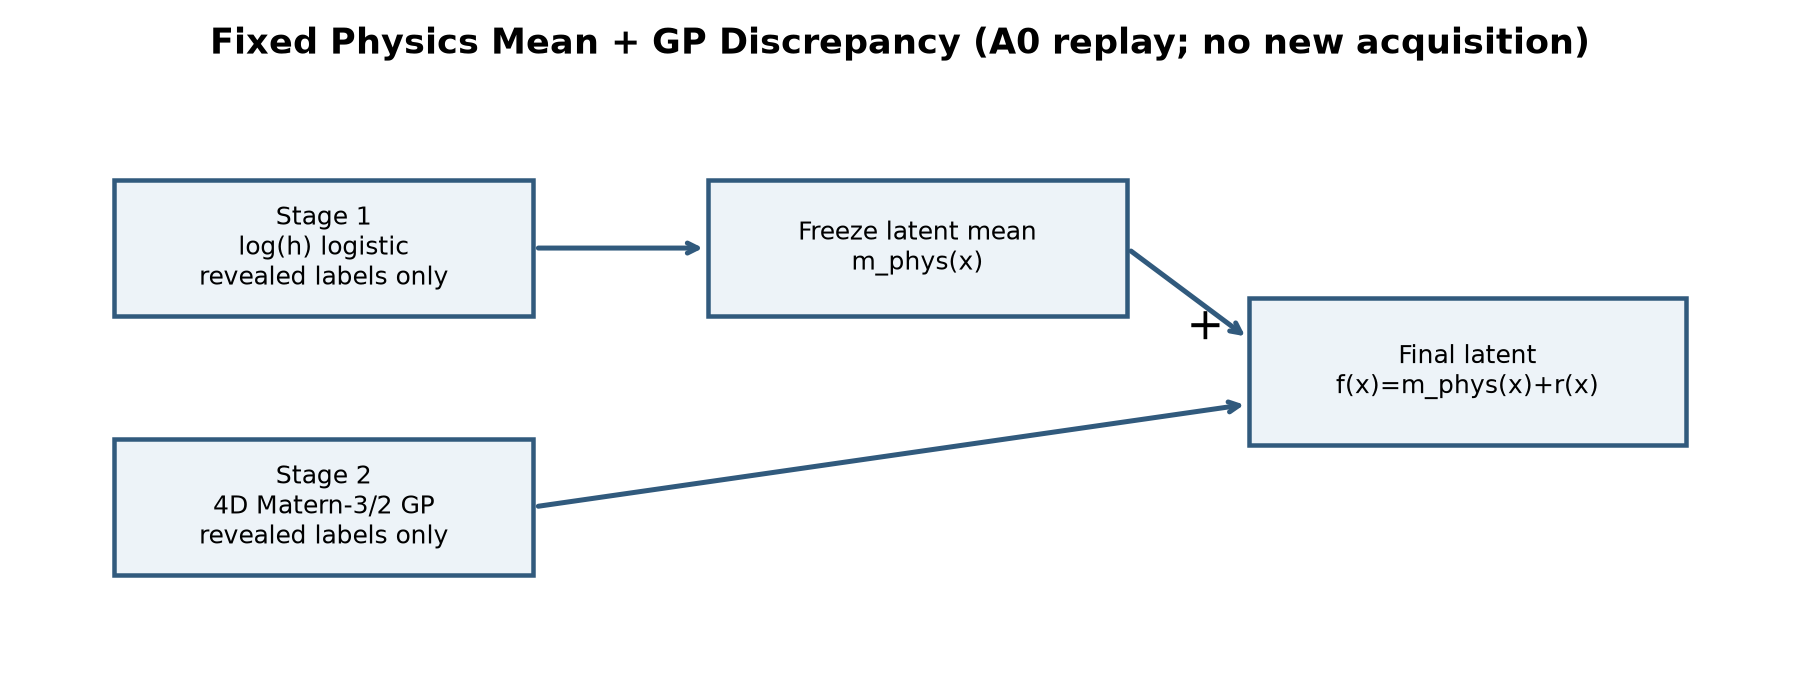

In [2]:
display(Image(filename=str(OUT/'figures'/'01_model_mechanism.png')))

## 3. Inference parity gate

The non-zero-mean implementation is independent of sklearn's private estimator. Its zero-mean mode must reproduce sklearn before scientific execution.

In [3]:
parity=json.loads((OUT/'implementation_parity_report.json').read_text()); display(parity)

{'equations': 'independent GPML logistic Laplace Algorithms 3.1/3.2/5.1; fixed mean enters latent f=m+g; zero-mean uses m=0',
 'fixed_kernel_cases': [{'case': 'toy',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 25},
  {'case': 'w85__r01_f01_B16',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81},
  {'case': 'w85__r10_f05_B40',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81},
  {'case': 'w85__r20_f05_B80',
   'max_absolute_probability_difference': 0.0,
   'mean_absolute_probability_difference': 0.0,
   'rows': 81}],
 'maximum_fixed_kernel_probability_difference': 0.0,
 'optimization_parity': [{'case': 'w85__r01_f01_B16',
   'custom_converged': True,
   'custom_iterations': 3,
   'custom_length_scale': 4.0,
   'custom_log_marginal_likelihood': -9.076359647212723,
   'custom_residual_sd': 1.0,
   'max_probabi

## 4. Same-path performance

M0, MH, M1 and M2 receive exactly the same A0 prefix at every budget.

,model,subset,mean_AULC,ci_lower,ci_upper
0,M0,B1_q20,0.813520,0.806801,0.820561
1,M0,B1_q30,0.866116,0.861578,0.870638
2,M1,B1_q20,0.829972,0.826466,0.833364
3,M1,B1_q30,0.871969,0.869469,0.874528
4,M2,B1_q20,0.830230,0.826788,0.833594
5,M2,B1_q30,0.871712,0.868841,0.874606
6,MH,B1_q20,0.830813,0.826714,0.835028
7,MH,B1_q30,0.871597,0.868791,0.874388


,contrast,subset,mean_difference,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
0,M2-M0,B1_q20,0.016710,0.010239,0.022992,18,0,2,10000
1,M2-M1,B1_q20,0.000257,-0.001438,0.002284,10,1,9,10000
2,M2-MH,B1_q20,-0.000584,-0.002440,0.001443,8,0,12,10000
3,M2-M0,B1_q30,0.005597,0.000325,0.010469,13,0,7,10000
4,M2-M1,B1_q30,-0.000256,-0.001556,0.001228,8,1,11,10000
5,M2-MH,B1_q30,0.000116,-0.001062,0.001419,10,0,10,10000


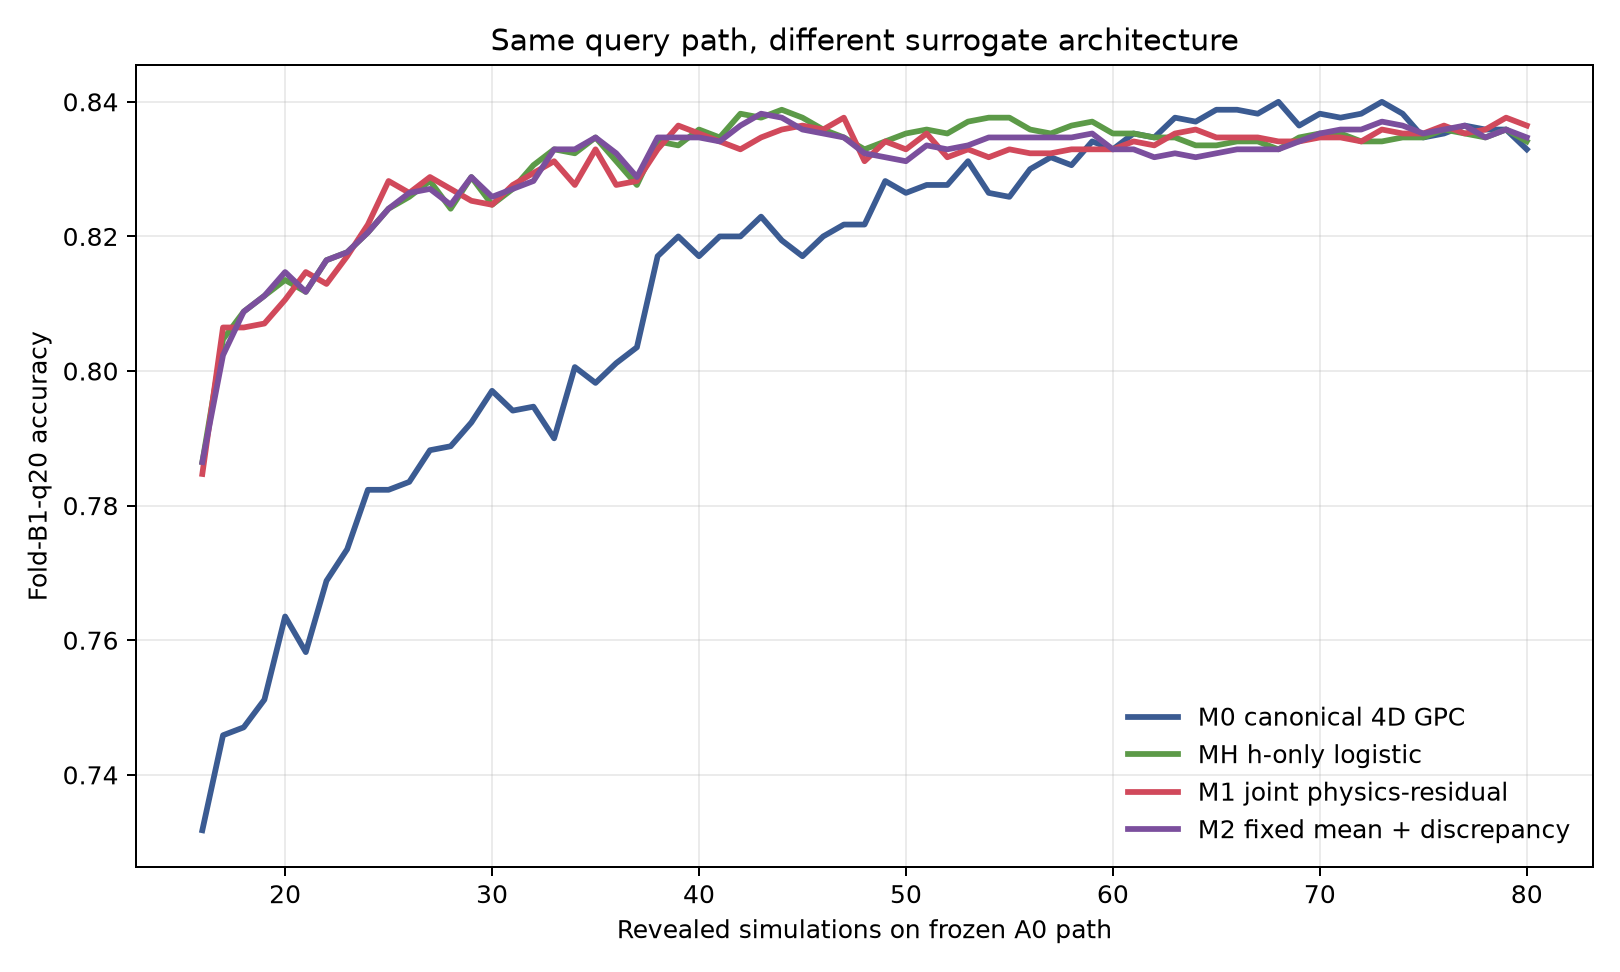

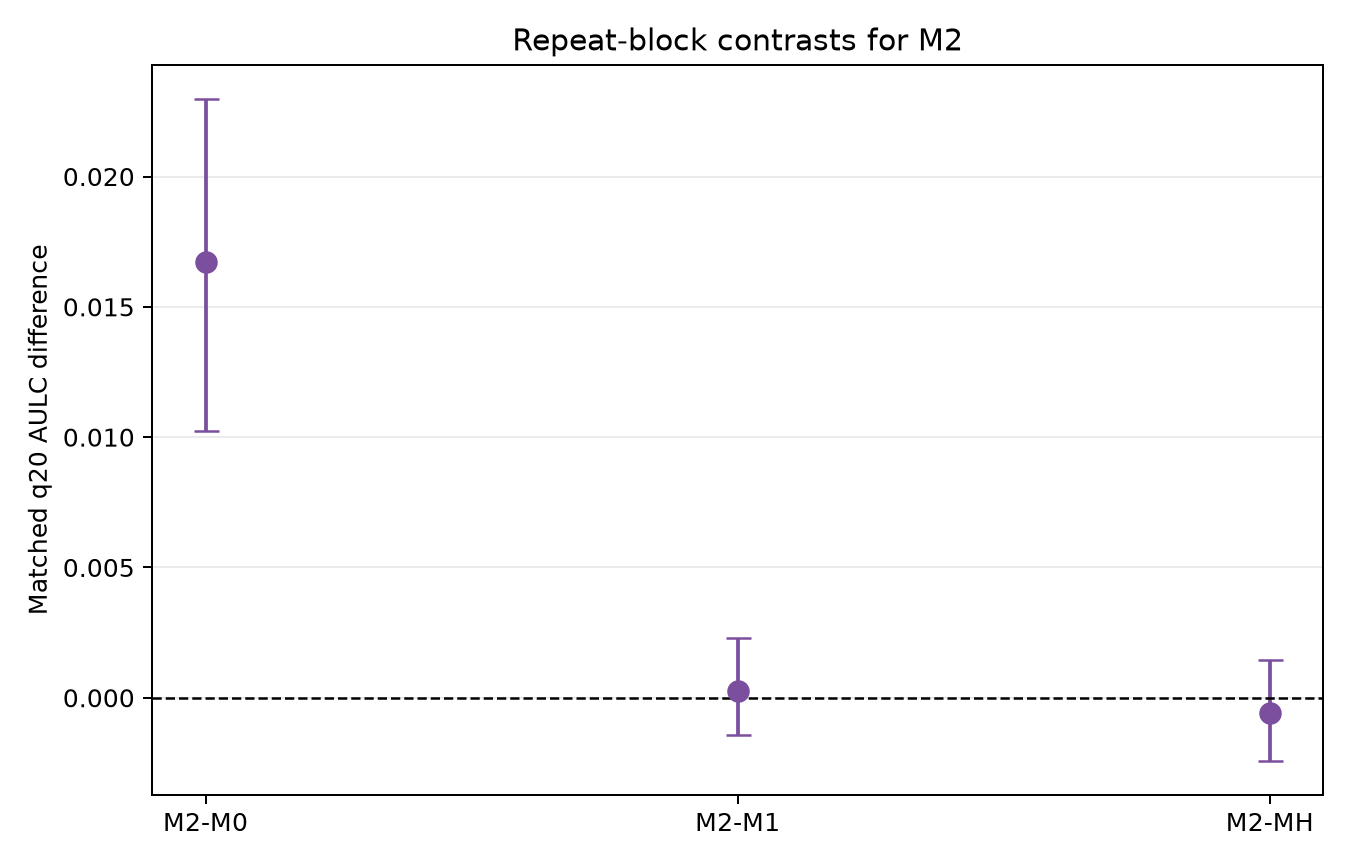

In [4]:
summary=pd.read_csv(OUT/'model_summary.csv'); contrasts=pd.read_csv(OUT/'paired_contrasts.csv'); display(summary); display(contrasts); display(Image(filename=str(OUT/'figures'/'02_q20_learning_curves.png'))); display(Image(filename=str(OUT/'figures'/'03_q20_aulc_contrasts.png')))

## 5. Low-data behavior at B16

In [5]:
display(pd.read_csv(OUT/'budget16_summary.csv')); display(pd.read_csv(OUT/'budget16_contrasts.csv'))

,model,subset,budget,metric,mean,ci_lower,ci_upper
0,M0,B1_q20,16,accuracy,0.731765,0.714118,0.750588
1,M0,B1_q20,16,balanced_accuracy,0.686194,0.659878,0.713796
2,M0,B1_q20,16,keyhole_recall,0.497492,0.431534,0.564256
3,M0,B1_q20,16,conduction_recall,0.874897,0.850677,0.899482
4,M0,B1_q20,16,false_negative,3.280000,2.860000,3.700000
5,M0,B1_q20,16,false_positive,1.280000,1.030000,1.530000
6,M1,B1_q20,16,accuracy,0.784706,0.767647,0.802353
7,M1,B1_q20,16,balanced_accuracy,0.770662,0.750608,0.789361
8,M1,B1_q20,16,keyhole_recall,0.722103,0.669399,0.773262
9,M1,B1_q20,16,conduction_recall,0.819220,0.784328,0.852706


,contrast,subset,budget,metric,mean_difference,ci_lower,ci_upper
0,M2-M0,B1_q20,16,accuracy,0.054706,0.031162,0.079412
1,M2-M0,B1_q20,16,balanced_accuracy,0.085123,0.059900,0.110886
2,M2-M0,B1_q20,16,keyhole_recall,0.221877,0.178971,0.265270
3,M2-M0,B1_q20,16,conduction_recall,-0.051632,-0.075109,-0.027855
4,M2-M0,B1_q20,16,false_negative,-1.480000,-1.750000,-1.200000
5,M2-M0,B1_q20,16,false_positive,0.550000,0.290000,0.800000
6,M2-M1,B1_q20,16,accuracy,0.001765,-0.002941,0.005882
7,M2-M1,B1_q20,16,balanced_accuracy,0.000655,-0.003785,0.004997
8,M2-M1,B1_q20,16,keyhole_recall,-0.002734,-0.013679,0.008968
9,M2-M1,B1_q20,16,conduction_recall,0.004044,-0.004831,0.013121


## 6. Residual stability

Bound hits are matched by run and A0 prefix. Raw warning counts are not used as the primary comparison.

,row_type,model,contrast,diagnostic,mean,ci_lower,ci_upper
0,model_rate,M1,NaN,residual_sd_lower_bound_hit,0.359077,0.339692,0.379692
1,model_rate,M1,NaN,residual_sd_upper_bound_hit,0.150769,0.128769,0.173235
2,model_rate,M1,NaN,residual_sd_any_bound_hit,0.509846,0.488923,0.531692
3,model_rate,M1,NaN,length_scale_lower_bound_hit,0.154462,0.121846,0.187538
4,model_rate,M1,NaN,length_scale_upper_bound_hit,0.175692,0.152612,0.197846
5,model_rate,M1,NaN,length_scale_any_bound_hit,0.330154,0.301073,0.360154
6,model_rate,M1,NaN,fit_failure_or_fallback,0.000000,0.000000,0.000000
7,model_rate,M2,NaN,residual_sd_lower_bound_hit,0.278462,0.247692,0.313077
8,model_rate,M2,NaN,residual_sd_upper_bound_hit,0.002769,0.000615,0.005692
9,model_rate,M2,NaN,residual_sd_any_bound_hit,0.281231,0.251692,0.316615


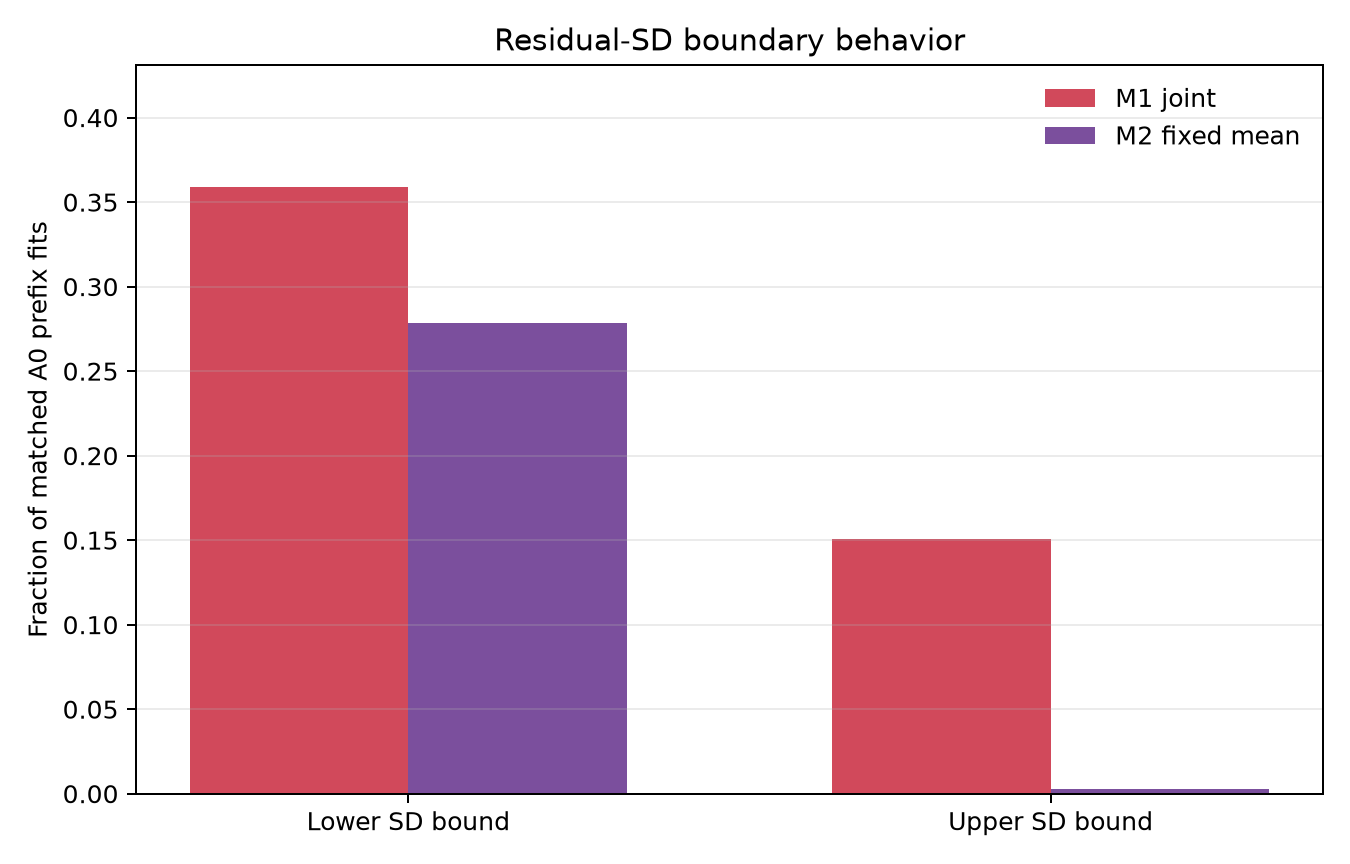

In [6]:
stability=pd.read_csv(OUT/'residual_stability_summary.csv'); display(stability); display(Image(filename=str(OUT/'figures'/'04_residual_sd_bound_hits.png')))

## 7. What this supports — and does not

Freezing removes direct re-optimization of the physics coefficient. It does **not** force the 4D residual to be orthogonal to h, solve identifiability, or establish acquisition superiority.

In [7]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_11_ONE_PAGE.md').read_text()))

# Supervisor Phase 1.11 â€” one page

**Decision:** FIXED_MEAN_SUPPORTED

- q20 AULC: M2 0.8302; M0 0.8135; M1 0.8300; h-only 0.8308.
- M2âˆ’M0: +0.0167 [+0.0102, +0.0230].
- M2âˆ’M1: +0.0003 [-0.0014, +0.0023].
- M2âˆ’h-only: -0.0006 [-0.0024, +0.0014]; the discrepancy adds no resolved predictive gain beyond h-only.
- Residual-SD any-bound rate: M1 51.0%; M2 28.1%.
- B16 q20 Keyhole recall: M0 0.497; MH 0.719; M1 0.722; M2 0.719.
- Fallbacks were 0%; M2 optimizer non-convergence flags occurred in 5.8% of fits.

All models saw identical A0 prefixes. The mean was learned from revealed labels only and frozen during GP fitting. M2 is cleaner than M1 on residual-SD bounds, but h-only remains the simpler equally predictive comparator. The residual still sees P, VX and LS, so orthogonality/identifiability is not claimed.
